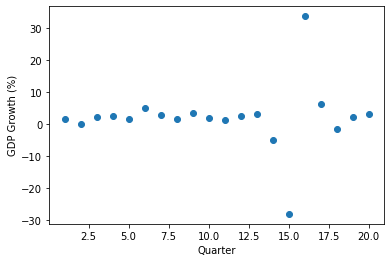

In [10]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(1,21)
y = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8,
              1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])
plt.scatter(x,y)
plt.xlabel('Quarter')
plt.ylabel('GDP Growth (%)')
plt.show()

This scatter plot is the dataset provided by the U.S. Bureau of Economic Analysis, showcasing quarterly GDP growth from 2010 to 2023. 20 of the full 56 quarterly data points are included in the given dataset. We will be applying 3 methods to interpolate the rest of the data: cubic spline interpolation, polynomial fitting, and least squares linear regression.

In [2]:
def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x) # Step sizes between data points
    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 2) # Subdiagonal
    B = np.zeros(n - 2) # Main diagonal
    C = np.zeros(n - 2) # Superdiagonal
    D = np.zeros(n - 2) # Right-hand side vector
    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        A[i - 1] = h[i-1] # Subdiagonal
        B[i - 1] = 2*(h[i-1] + h[i]) # Main diagonal
        C[i - 1] = h[i] # Superdiagonal
        D[i - 1] = 6*(((y[i + 1]-y[i])/h[i]) - (y[i] - y[i - 1]) / h[i - 1]) # Right-hand side vector
    return A, B, C, D

In [3]:
def thomas_algorithm(a, b, c, d):
    """
    Solve the tridiagonal system using the Thomas algorithm.
    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)
    Returns: solution vector x of length n
    """
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

In [4]:
def evaluate_spline(x_data, y_data, M, x_query):
    """M: second derivatives; M[0]=M[-1]=0 for natural spline"""
    n = len(x_data)
    h = np.diff(x_data) # step sizes
    i = np.searchsorted(x_data, x_query, side='right') - 1
    i = np.clip(i, 0, n - 2) # find interval
    hi = h[i]
    dx_left = x_query - x_data[i] # (x - xᵢ)
    dx_right = x_data[i+1] - x_query # (xᵢ₊₁ - x)
    S = (
        (M[i] / (6*hi)) * dx_right**3 + # Term 1
        (M[i+1] / (6*hi)) * dx_left**3 + # Term 2
        (y_data[i] /hi - M[i] *hi/6) * dx_right + # Term 3
        (y_data[i+1] /hi - M[i+1] *hi/6) * dx_left # Term 4
    )
    return S

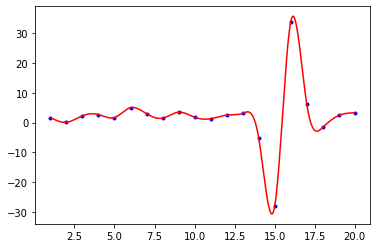

In [5]:
# Set up the tridiagonal matrix for the cubic spline
A, B, C, D = setup_tridiagonal_matrix(x, y)

M = np.zeros(len(x))
M[1:-1] = thomas_algorithm(A, B, C, D)

x_spline = np.arange(x[0], x[-1], 0.01)
y_spline = evaluate_spline(x, y, M, x_spline)

plt.scatter(x, y, 'b.')
plt.plot(x_interp, y_interp, 'r-')
plt.xlabel('Quarter')
plt.ylabel('GDP Growth (%)')
plt.show()

1. To create the cubic spline interpolation, we first set up a system of equations that relates the second derivatives at each knot in the form of a tridiagonal matrix, using the Thomas algorithm to solve it. For n data points, there are n-2 unknowns that the Thomas algorithm solves for to satisfy continuity conditions, ensuring that the first and second derivatives of the splines are continuous at the internal points. To satisfy boundary conditions for a natural spline, the second derivatives at the endpoints are set to zero.

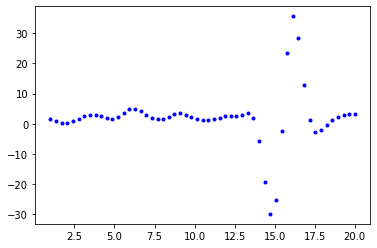

In [9]:
x_interp = np.linspace(x[0], x[-1], 55)
y_interp = evaluate_spline(x, y, M, x_interp)

plt.scatter(x_interp, y_interp, 'b.')
plt.xlabel('Quarter')
plt.ylabel('GDP Growth (%)')
plt.show()

2. The interpolant does appear visually smooth, but it is questionable whether the interpolant is reasonable close to outlying data points such as 2020 Q2 and 2020 Q3. Since cubic splines are not robust to noise, interpolated GDP growth data near them may not be accurate.

3. 